In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1)
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
X = X.drop(columns=['Sex'])

In [3]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [ ]:
from experiment import run_parallel_experiments

m_try_settings = [1, 5, 10, 20, 50]

all_results = {}

for m_tries in m_try_settings:
    notebook_name = f"real1_Abalone_mtry{m_tries}"
    print(f"Running: {notebook_name} (m_tries={m_tries})")

    results = run_parallel_experiments(
        X=X,
        y=y,
        ndpost=7000,
        nskip=3000,           # burn-in
        n_trees=100,
        notebook=notebook_name,
        tree_alpha=0.95,
        tree_beta=2.0,
        m_tries=m_tries,
        n_runs=3, # TODO: Increase to 5 or more
        n_chains=4,
        n_jobs=-2,
        base_split_seed=42,
        base_chain_seed=2026,
        store_preds=True,
        n_test_points=100,
        start_temp=1.0,
        end_temp=1.0,
        store_dir="store"
    )

    all_results[notebook_name] = results

print("All m_tries settings finished.")

# Results

Using STORE_DIR: C:\Users\ztykk\Phd\BART\bart-playground\diagnosis\m-tries\store
Detected m_tries: ['mtry1', 'mtry5', 'mtry10', 'mtry20', 'mtry50']
Detected runs: [0, 1, 2]
MTMH RMSE table (rows=m_tries, cols=run)


,run000,run001,run002
mtry1,1.945942,2.058211,1.889172
mtry5,1.901275,2.072959,1.887999
mtry10,1.942022,2.091309,1.883808
mtry20,1.920397,2.084551,1.893222
mtry50,1.934512,2.074971,1.881883


MTMH CRPS table (rows=m_tries, cols=run)


,run000,run001,run002
mtry1,1.087466,1.132011,0.959181
mtry5,1.067689,1.133191,0.951062
mtry10,1.089270,1.142673,0.948300
mtry20,1.078109,1.139990,0.950958
mtry50,1.084866,1.134440,0.948376



===== Run 000 =====


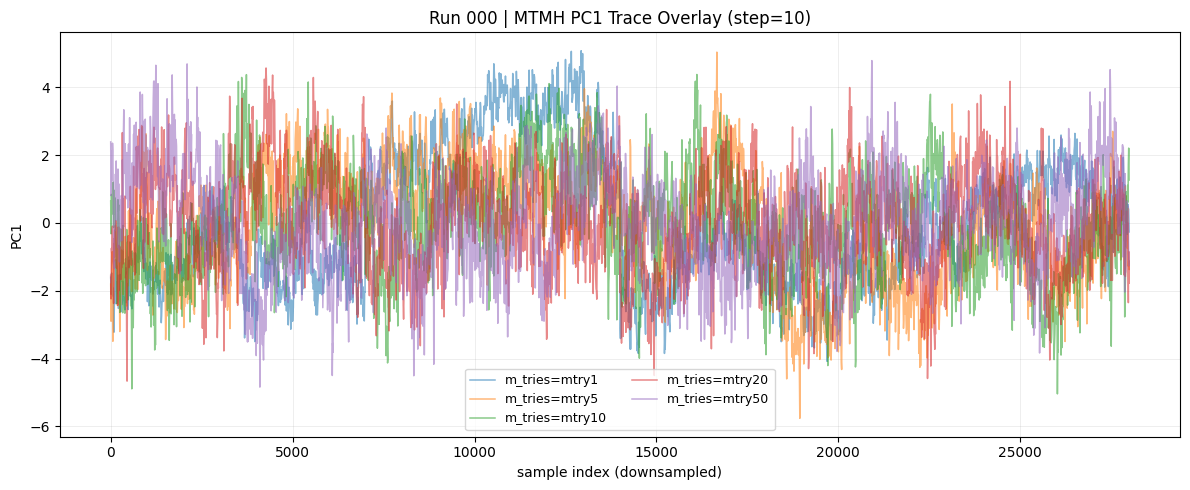

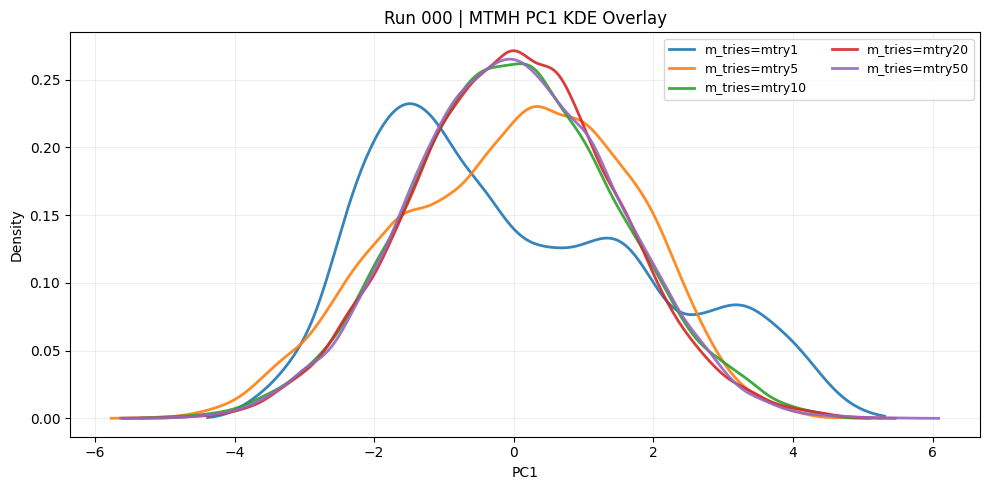

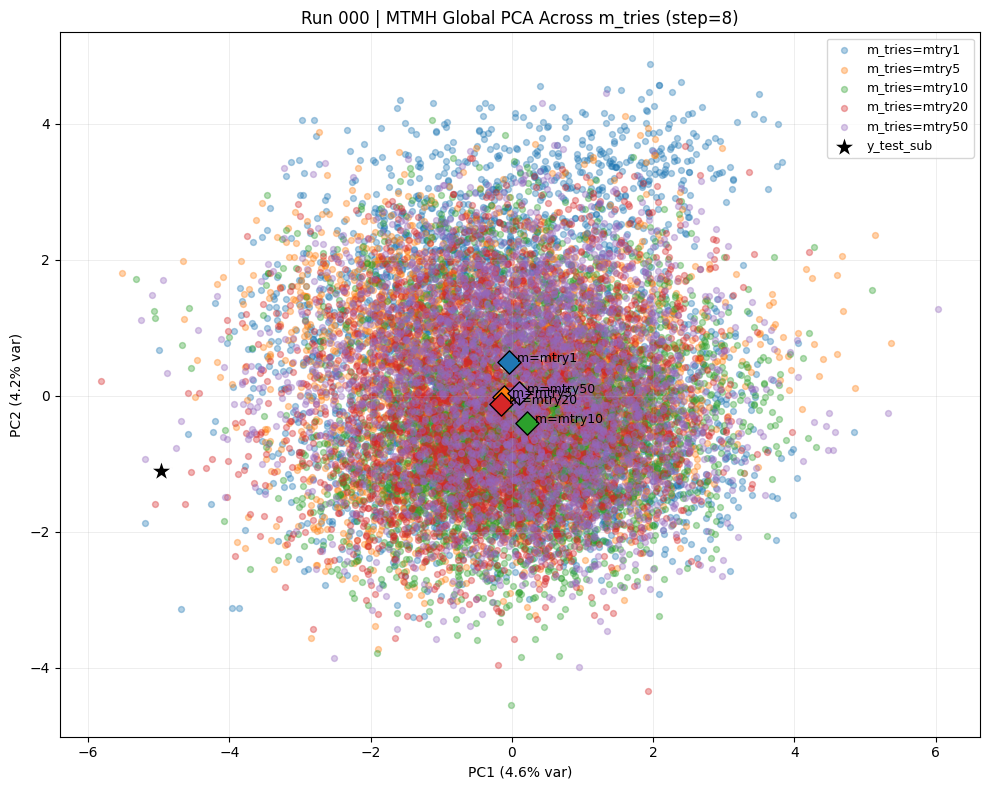


===== Run 001 =====


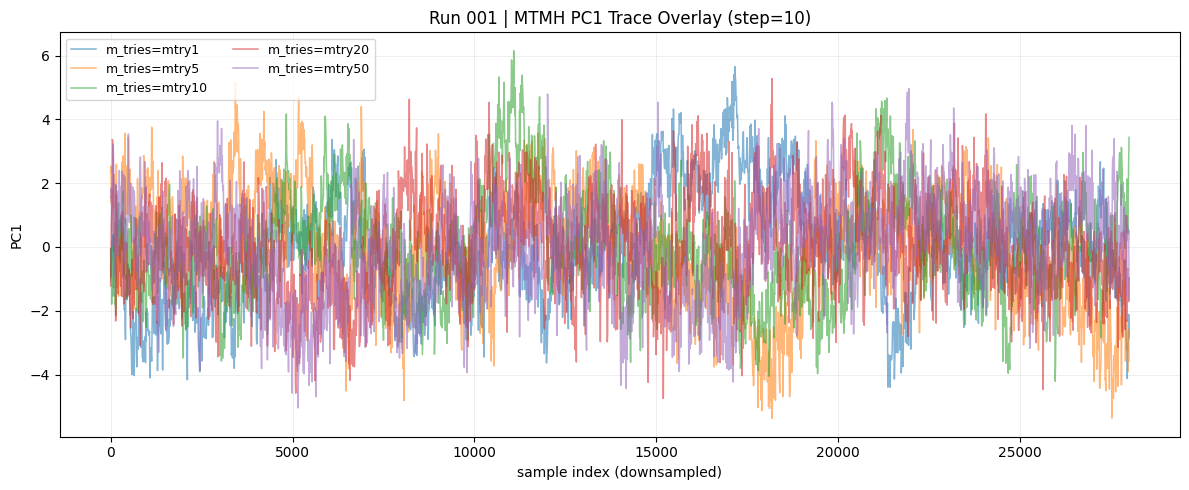

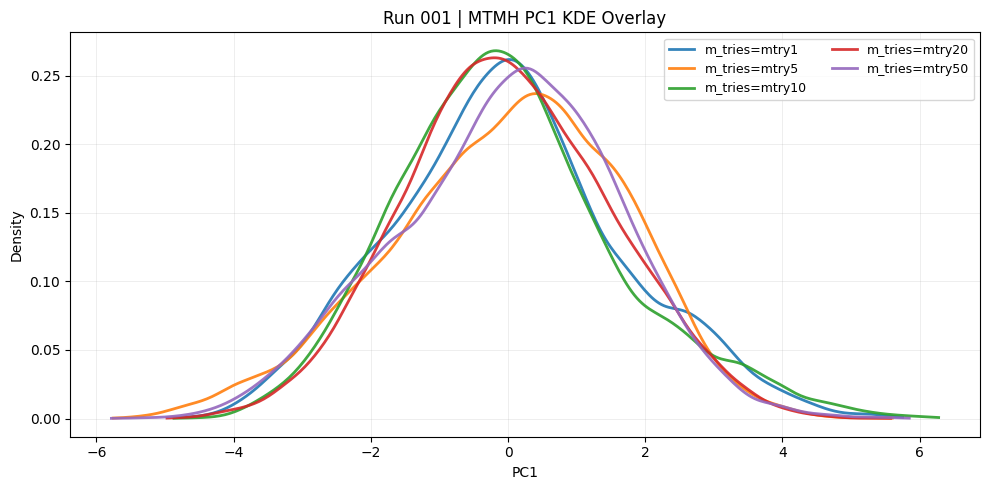

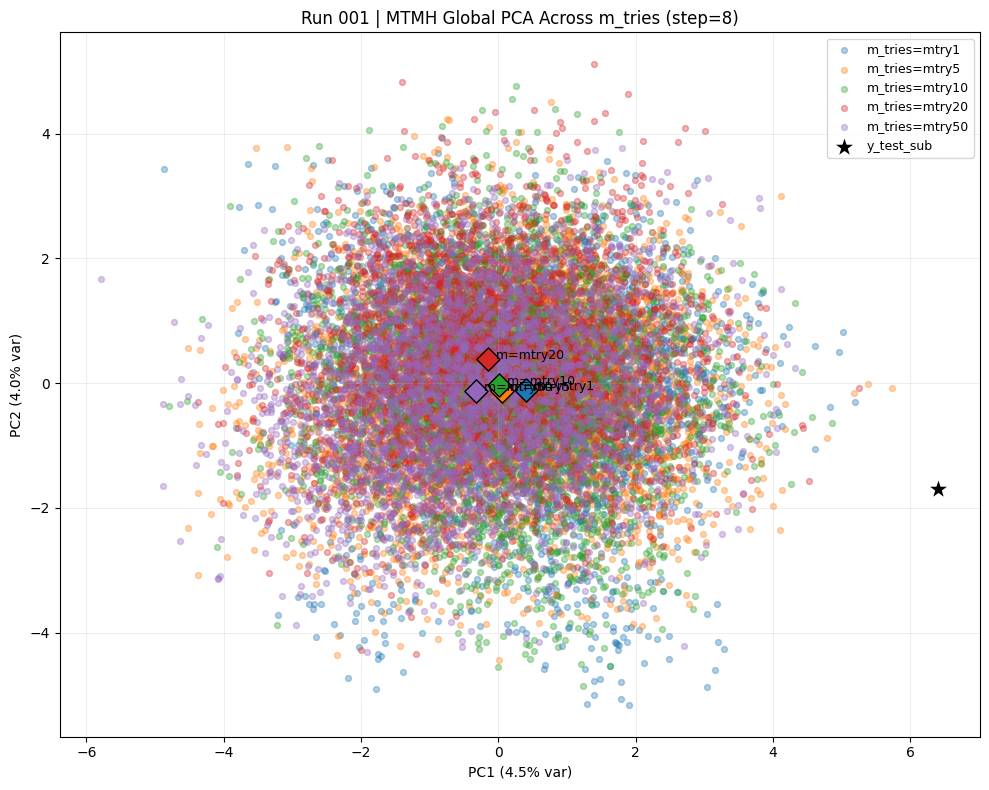


===== Run 002 =====


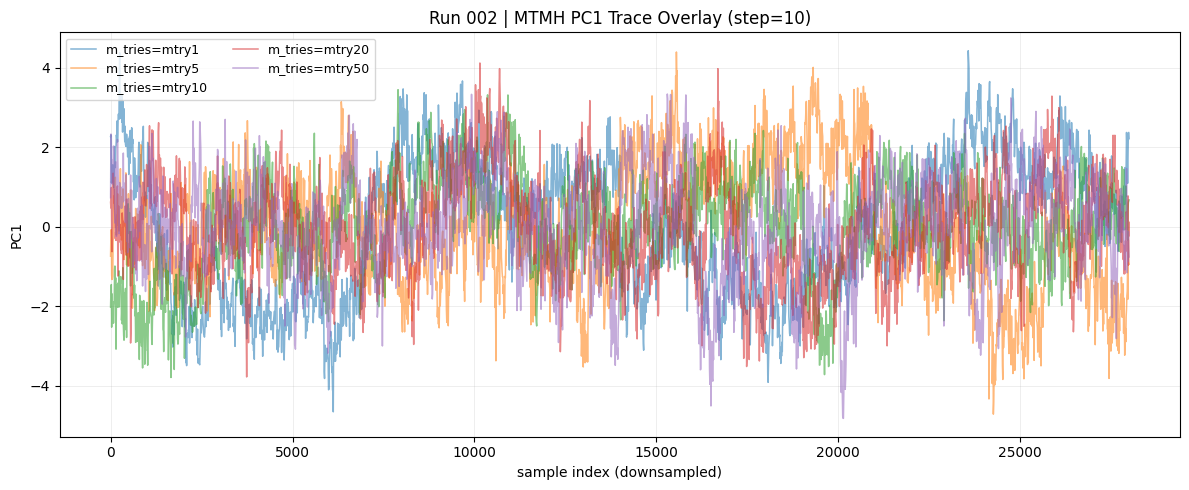

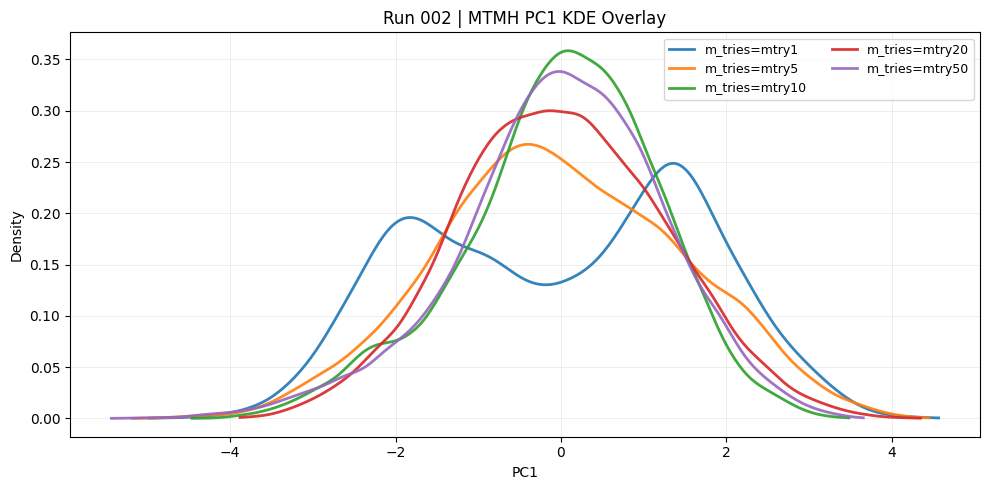

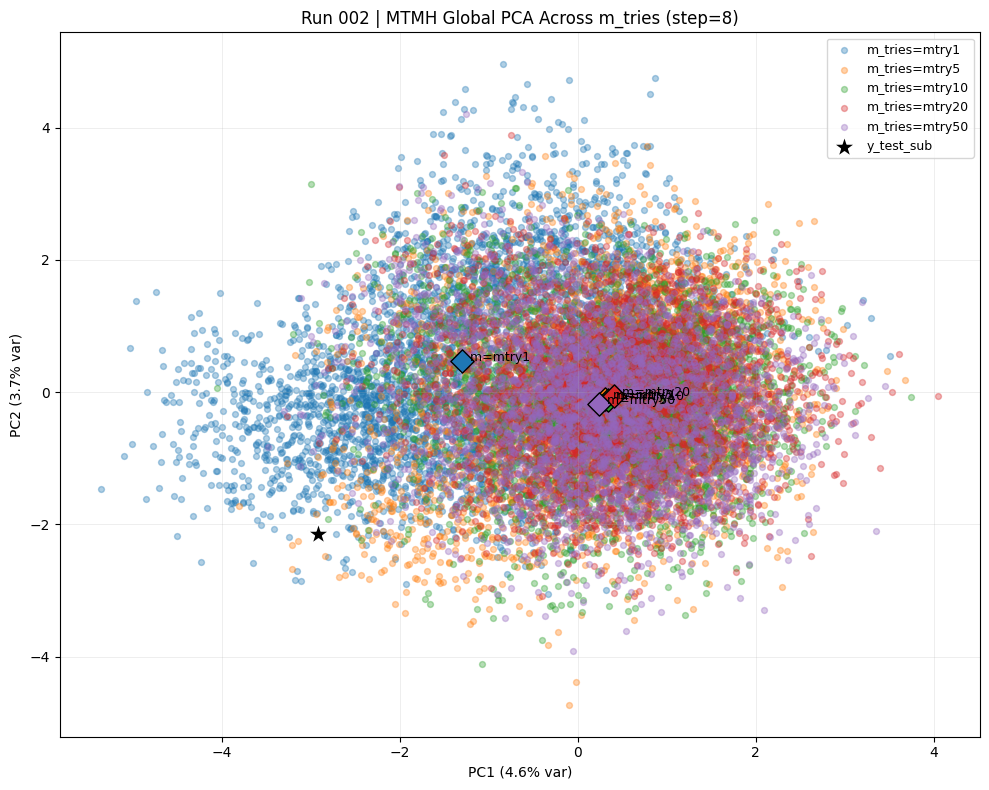

In [5]:
import re
import ast
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from IPython.display import display

NOTEBOOK_PREFIX = "real1_Abalone"
STORE_DIR = Path("store")
print("Using STORE_DIR:", STORE_DIR.resolve())

def _parse_shape_from_header(csv_path):
    with open(csv_path, "r", encoding="utf-8") as f:
        first_line = f.readline().strip()
    first_line = first_line.lstrip("#").strip()
    if not first_line.startswith("original_shape="):
        raise ValueError(f"Missing original_shape header in {csv_path}")
    return ast.literal_eval(first_line.split("=", 1)[1].strip())

def load_saved_numeric_csv(csv_path):
    shape = _parse_shape_from_header(csv_path)
    arr2d = np.loadtxt(csv_path, delimiter=",", comments="#")
    if arr2d.size == 0:
        return np.array([])
    if arr2d.ndim == 0:
        arr2d = arr2d.reshape(1, 1)
    elif arr2d.ndim == 1:
        arr2d = arr2d.reshape(1, -1)
    return arr2d.reshape(shape)

def _mtry_sort_key(label):
    m = re.search(r"mtry(\d+)$", label)
    if m:
        return int(m.group(1))
    return label

def discover_mtries_and_runs(prefix=NOTEBOOK_PREFIX):
    rmse_dir = STORE_DIR / "subsample_rmse"
    pattern = re.compile(
        rf"^{re.escape(prefix)}_(?P<mtry>[^_]+)__run(?P<run>\d{{3}})__mtmh__subsample_rmse\.csv$"
    )
    mtry_to_runs = {}
    for p in rmse_dir.glob(f"{prefix}_*__mtmh__subsample_rmse.csv"):
        m = pattern.match(p.name)
        if m is None:
            continue
        mtry_label = m.group("mtry")
        run = int(m.group("run"))
        mtry_to_runs.setdefault(mtry_label, set()).add(run)

    if not mtry_to_runs:
        sample_files = [q.name for q in rmse_dir.glob("*__mtmh__subsample_rmse.csv")][:10]
        raise FileNotFoundError(
            f"No MTMH files found in {rmse_dir} for prefix '{prefix}'. "
            f"Sample MTMH files in this dir: {sample_files}"
        )

    mtries = sorted(mtry_to_runs.keys(), key=_mtry_sort_key)
    runs = sorted(set().union(*mtry_to_runs.values()))
    return mtries, runs

def build_metric_pivots(mtries, runs, prefix=NOTEBOOK_PREFIX):
    rmse_pivot = pd.DataFrame(index=mtries, columns=[f"run{r:03d}" for r in runs], dtype=float)
    crps_pivot = pd.DataFrame(index=mtries, columns=[f"run{r:03d}" for r in runs], dtype=float)

    for run_id in runs:
        for mtry_label in mtries:
            base = f"{prefix}_{mtry_label}__run{run_id:03d}"
            rmse_path = STORE_DIR / "subsample_rmse" / f"{base}__mtmh__subsample_rmse.csv"
            crps_path = STORE_DIR / "subsample_crps" / f"{base}__mtmh__subsample_crps.csv"
            if not (rmse_path.exists() and crps_path.exists()):
                continue

            rmse_vals = load_saved_numeric_csv(rmse_path).reshape(-1)
            crps_vals = load_saved_numeric_csv(crps_path).reshape(-1)
            rmse_pivot.loc[mtry_label, f"run{run_id:03d}"] = float(np.mean(rmse_vals))
            crps_pivot.loc[mtry_label, f"run{run_id:03d}"] = float(np.mean(crps_vals))

    return rmse_pivot, crps_pivot

def load_mtmh_preds_for_mtry_run(mtry_label, run_id, prefix=NOTEBOOK_PREFIX):
    base = f"{prefix}_{mtry_label}__run{run_id:03d}"
    pred_path = STORE_DIR / "preds" / f"{base}__mtmh__preds.csv"
    if not pred_path.exists():
        return None
    return load_saved_numeric_csv(pred_path)  # [n_chains, n_test, ndpost]

def load_y_test_sub_for_run(run_id, mtries, prefix=NOTEBOOK_PREFIX):
    for mtry_label in mtries:
        p = STORE_DIR / "subsample_y_test" / f"{prefix}_{mtry_label}__run{run_id:03d}__subsample_y_test.csv"
        if p.exists():
            return load_saved_numeric_csv(p).reshape(-1)
    return None

def preds_to_matrix(preds):
    # [n_chains, n_test, ndpost] -> [n_chains * ndpost, n_test]
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(n_chains * ndpost, n_test)

def collect_pc_matrices_for_run(run_id, mtries, prefix=NOTEBOOK_PREFIX):
    mats = {}
    for mtry_label in mtries:
        preds = load_mtmh_preds_for_mtry_run(mtry_label, run_id, prefix=prefix)
        if preds is None:
            continue
        mats[mtry_label] = preds_to_matrix(preds)
    return mats

def plot_pc1_trace_overlay(run_id, mats, mtries, downsample_step=10):
    if not mats:
        print(f"Run {run_id:03d}: no MTMH prediction files found, skip PC1 trace.")
        return

    palette = plt.get_cmap("tab10")
    plt.figure(figsize=(12, 5))
    for i, mtry_label in enumerate(mtries):
        if mtry_label not in mats:
            continue
        pc1 = PCA(n_components=1).fit_transform(mats[mtry_label])[:, 0]
        idx = np.arange(pc1.shape[0])[::downsample_step]
        plt.plot(
            idx,
            pc1[idx],
            alpha=0.55,
            linewidth=1.1,
            color=palette(i % 10),
            label=f"m_tries={mtry_label}",
        )

    plt.title(f"Run {run_id:03d} | MTMH PC1 Trace Overlay (step={downsample_step})")
    plt.xlabel("sample index (downsampled)")
    plt.ylabel("PC1")
    plt.grid(alpha=0.25, linewidth=0.6)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_pc1_kde_overlay(run_id, mats, mtries):
    if not mats:
        print(f"Run {run_id:03d}: no MTMH prediction files found, skip PC1 KDE.")
        return

    palette = plt.get_cmap("tab10")
    plt.figure(figsize=(10, 5))
    for i, mtry_label in enumerate(mtries):
        if mtry_label not in mats:
            continue
        pc1 = PCA(n_components=1).fit_transform(mats[mtry_label])[:, 0]
        if pc1.size < 2 or np.std(pc1) == 0:
            continue
        kde = gaussian_kde(pc1)
        xgrid = np.linspace(np.min(pc1), np.max(pc1), 300)
        plt.plot(
            xgrid,
            kde(xgrid),
            linewidth=2.0,
            alpha=0.9,
            color=palette(i % 10),
            label=f"m_tries={mtry_label}",
        )

    plt.title(f"Run {run_id:03d} | MTMH PC1 KDE Overlay")
    plt.xlabel("PC1")
    plt.ylabel("Density")
    plt.grid(alpha=0.25, linewidth=0.6)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_pc1_pc2_scatter_global_pca(run_id, mats, mtries, prefix=NOTEBOOK_PREFIX, downsample_step=8):
    if not mats:
        print(f"Run {run_id:03d}: no MTMH prediction files found, skip PC1-PC2 scatter.")
        return

    available_mtries = [m for m in mtries if m in mats]
    X_all = np.vstack([mats[m] for m in available_mtries])
    pca = PCA(n_components=2)
    pcs_all = pca.fit_transform(X_all)

    y_test_sub = load_y_test_sub_for_run(run_id, available_mtries, prefix=prefix)
    y_proj = None
    if y_test_sub is not None and y_test_sub.shape[0] == X_all.shape[1]:
        y_proj = pca.transform(y_test_sub.reshape(1, -1))[0]

    palette = plt.get_cmap("tab10")
    color_map = {m: palette(i % 10) for i, m in enumerate(available_mtries)}

    plt.figure(figsize=(10, 8))
    cursor = 0
    for m in available_mtries:
        n = mats[m].shape[0]
        idx_full = np.arange(cursor, cursor + n)
        idx = idx_full[::downsample_step]
        pts = pcs_all[idx_full, :]

        plt.scatter(
            pcs_all[idx, 0],
            pcs_all[idx, 1],
            s=18,
            alpha=0.35,
            color=color_map[m],
            label=f"m_tries={m}",
        )

        centroid = pts.mean(axis=0)
        plt.scatter(
            centroid[0],
            centroid[1],
            s=140,
            color=color_map[m],
            edgecolors="black",
            linewidths=1.0,
            marker="D",
            zorder=6,
        )
        plt.text(
            centroid[0],
            centroid[1],
            f"  m={m}",
            fontsize=9,
            color="black",
            zorder=7,
        )

        cursor += n

    if y_proj is not None:
        plt.scatter(
            y_proj[0],
            y_proj[1],
            s=280,
            c="black",
            marker="*",
            edgecolors="white",
            linewidths=1.2,
            label="y_test_sub",
            zorder=10,
        )

    evr = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
    plt.title(f"Run {run_id:03d} | MTMH Global PCA Across m_tries (step={downsample_step})")
    plt.grid(alpha=0.25, linewidth=0.6)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), fontsize=9, loc="best")
    plt.tight_layout()
    plt.show()

mtries, runs = discover_mtries_and_runs(prefix=NOTEBOOK_PREFIX)
print("Detected m_tries:", mtries)
print("Detected runs:", runs)

rmse_pivot, crps_pivot = build_metric_pivots(mtries, runs, prefix=NOTEBOOK_PREFIX)
print("MTMH RMSE table (rows=m_tries, cols=run)")
display(rmse_pivot)
print("MTMH CRPS table (rows=m_tries, cols=run)")
display(crps_pivot)

for run_id in runs:
    print(f"\n===== Run {run_id:03d} =====")
    mats = collect_pc_matrices_for_run(run_id, mtries, prefix=NOTEBOOK_PREFIX)

    # 1) PC1 trace plot: all m_tries on one canvas.
    plot_pc1_trace_overlay(run_id, mats, mtries, downsample_step=10)

    # 2) PC1 KDE plot: all m_tries on one canvas.
    plot_pc1_kde_overlay(run_id, mats, mtries)

    # 3) PC1 vs PC2 scatter: global PCA across all m_tries, with centroids and y_test_sub.
    plot_pc1_pc2_scatter_global_pca(run_id, mats, mtries, prefix=NOTEBOOK_PREFIX, downsample_step=8)